# Course tools and Python foundations

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/01-course-tools.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

This notebook introduces the small set of Python tools used throughout the course. It is not a comprehensive Python tutorial: the goal is to be comfortable loading, inspecting, selecting, filtering, and plotting engineering data.
本笔记本介绍了一小套贯穿整个课程的 Python 工具。它并非全面的 Python 教程：目标是让读者能够熟练地加载、检查、选择、筛选和绘制工程数据。

**Learning objectives**

- Use NumPy arrays for basic numerical calculations.
- Load a public dataset into a Pandas DataFrame.
- Select columns and filter rows using clear, readable code.
- Make and interpret a simple engineering-data plot.
**学习目标**
- 使用 NumPy 数组进行基本数值计算。
- 将公开数据集加载到 Pandas DataFrame 中。
- 使用清晰易读的代码选择列和筛选行。
- 绘制并解读简单的工程数据图。

## 1. Import the Python libraries

The next cell demonstrates how to import a Python library.

`import numpy as np` makes the NumPy library available in this notebook. The `as` keyword assigns the short alias `np` to NumPy's namespace, so we can write `np.array(...)` instead of the longer `numpy.array(...)`. Using `np` is a common convention in scientific Python.下一个单元格演示了如何导入 Python 库。
`import numpy as np` 使 NumPy 库在此笔记本中可用。`as` 关键字将 NumPy 的命名空间指定为短别名 `np`，这样我们就可以写 `np.array(...)` 而不是更长的 `numpy.array(...)`。在科学 Python 中，使用 `np` 是一种常见的约定。

In [7]:
# Import NumPy first: it is the numerical-array tool used in this section.
import numpy as np

## 2. Numerical arrays

A NumPy array stores a collection of numerical values. Array operations act element-by-element, which makes calculations compact and readable.
2. 数值数组
NumPy 数组存储一系列数值。数组运算逐元素进行，这使得计算过程简洁易读。

In [8]:
# Store repeated temperature measurements in a one-dimensional numerical array.
temperatures_c = np.array([15.2, 18.7, 21.4, 24.1])
# NumPy applies this unit conversion to every element of the array at once.
temperatures_k = temperatures_c + 273.15

print("Temperatures in K:", temperatures_k)
print(f"Mean temperature: {temperatures_c.mean():.1f} °C")
print(f"Range: {temperatures_c.min():.1f}–{temperatures_c.max():.1f} °C")
#这段代码演示了利用 **NumPy 数组**高效处理工程数据的基本用法，核心拆解如下：

#* **数据存储**：用 `np.array()` 创建一维数组，集中管理传感器连续采集的温度数据。
#* **向量化运算**：直接对数组执行 `+ 273.15`，触发**广播机制**批量完成单位转换（摄氏度转开尔文），免去写 `for` 循环。
#* **统计分析**：调用内置函数 `.mean()`、`.min()` 和 `.max()` 快速提取数据的平均值与极差，进行基础的数据特征分析。
#摄氏度：Celsius（全称 Degree Celsius，符号 °C）
#开尔文：Kelvin（符号 K，注意开尔文前通常不加 "degree"，直接称 Kelvin）

Temperatures in K: [288.35 291.85 294.55 297.25]
Mean temperature: 19.9 °C
Range: 15.2–24.1 °C


The array is useful for a single quantity observed repeatedly. A table with many named variables is better represented by a Pandas **DataFrame**.

Compared with a native Python list, a NumPy array is designed for numerical work. It supports vectorized calculations—such as adding `273.15` to every temperature—in one clear operation, stores values efficiently, and is much faster for the large arrays used in data analysis and machine learning.
对于重复观测的单个量，数组非常有用。而对于包含多个命名变量的表格，Pandas DataFrame 则更为合适。

与 Python 原生列表相比，NumPy 数组专为数值运算而设计。它支持向量化计算（例如，只需一次操作即可将 273.15 加到每个温度值上），能够高效地存储数值，并且在数据分析和机器学习中使用的大型数组方面速度更快。

## 3. Load the course dataset

The Gas Turbine CO and NOx Emissions dataset records the operation of a gas turbine between 2011 and 2015. It combines ambient conditions, turbine sensor measurements, energy yield, and two emissions outcomes: carbon monoxide (CO) and nitrogen oxides (NOx).

Each row represents one hourly observation of the system: the measured operating and environmental conditions during that hour, together with the emissions observed at that time. This course returns to the same dataset repeatedly so that the modeling choices remain connected to a physical system.

The original data and documentation are available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set).燃气轮机一氧化碳和氮氧化物排放数据集记录了2011年至2015年间燃气轮机的运行情况。该数据集整合了环境条件、涡轮传感器测量值、能量输出以及两种排放结果：一氧化碳 (CO) 和氮氧化物 (NOx)。

每一行代表系统每小时的观测值：包括该小时内测量的运行和环境条件，以及该时间段内观测到的排放量。本课程会反复使用同一数据集，以确保建模选择与实际物理系统紧密相关。

原始数据和文档可从加州大学尔湾分校机器学习库获取。

In [9]:
# Pandas represents a table with named columns as a DataFrame.
import pandas as pd
from pathlib import Path
from urllib.request import urlretrieve

# Use the committed course version so everyone analyzes the same data.
DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
#pathlib.Path：Python 处理文件路径的标准库，比传统的 os.path 更跨平台且直观。
#urlretrieve：用于直接从指定的网络 URL 下载文件到本地。
#DATA_URL：定义了课程 GitHub 仓库中的燃气轮机（Gas Turbine）数据集地址。

# Prefer a local copy; otherwise download it when this notebook runs independently.
data_path = next(
    (path for path in [
        Path("../data/gas-turbine-course.csv"),
        Path("site/data/gas-turbine-course.csv"),
        Path("gas-turbine-course.csv")]
        if path.exists()
    ),
    Path("gas-turbine-course.csv"),
)
#核心逻辑：自动检查常见的文件存放路径（上级目录、子目录或当前目录）。
#path.exists()：检查路径下的文件是否存在。
#next(..., default)：返回生成器中第一个存在的文件路径；如果三个路径都不存在，则默认指定落脚点为当前目录下的 "gas-turbine-course.csv"。
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)
data = pd.read_csv(data_path)
#条件下载：如果本地没有找到数据集，则触发 urlretrieve 从 GitHub 下载，避免每次运行代码都重复下载。
#pd.read_csv()：将 CSV 文件读取并转换为 Pandas 的核心数据结构 DataFrame（二维表格）。

# Inspect the dataset size before selecting variables or fitting a model.
print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
data.head()
#len(data):,：获取行数，:, 格式化会在数字中加入千位分隔符（如 36,733）。
#data.shape[1]：shape 返回元组 (行数, 列数)，取索引 1 即列数（特征数）。
#data.head()：默认预览表格的前 5 行数据，用于快速确认数据加载是否正常、各列字段名（如温度、压力、排气浓度等）是否正确。

Rows: 36,733
Columns: 12


,campaign_year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


A good first habit is to inspect the column names and units before modeling. This data dictionary identifies every column in the course dataset.养成建模前检查列名和单位的好习惯。此数据字典列出了课程数据集中的每一列。

| Variable | Meaning |
|:--|:--|
| `AT` | Ambient temperature (°C) |
| `AP` | Ambient pressure (mbar) |
| `AH` | Ambient humidity (%) |
| `AFDP` | Air filter differential pressure (mbar) |
| `GTEP` | Gas turbine exhaust pressure (mbar) |
| `TIT` | Turbine inlet temperature (°C) |
| `TAT` | Turbine after temperature (°C) |
| `TEY` | Turbine energy yield (MWh) |
| `CDP` | Compressor discharge pressure (mbar) |
| `CO` | Carbon monoxide emissions (mg/m³) |
| `NOX` | Nitrogen oxides emissions (mg/m³) |
变量含义

AT 环境温度 (°C)

AP 环境压力 (mbar)

AH 环境湿度 (%)

AFDP 空气过滤器压差 (mbar)

GTEP 燃气轮机排气压力 (mbar)

TIT 涡轮机入口温度 (°C)

TAT 涡轮机出口温度 (°C)

TEY 涡轮机能量输出 (MWh)

CDP 压缩机排气压力 (mbar)

CO 一氧化碳排放量 (mg/m³)

NOx 氮氧化物排放量 (mg/m³)

## 4. Select and filter data

Data analysis often begins with two simple operations: selecting the **columns** (variables) relevant to a question and filtering the **rows** (observations) that meet a condition. The next cell demonstrates both operations on the gas-turbine data.

4. 选择和筛选数据

数据分析通常从两个简单的操作开始：选择与问题相关的列（变量）和筛选符合条件的行（观测值）。下一个单元格演示了对燃气轮机数据执行这两个操作的过程。

In [12]:
# Select a small set of ambient, turbine, and emissions variables for inspection.
selected = data[["AT", "TIT", "TEY", "CO", "NOX"]] #从原始 DataFrame 中挑选出 5 个关键的燃气轮机运行变量，生成一个新的子数据集 selected
# Use the median to divide the observations into relatively warmer and cooler conditions.
warm_conditions = selected[selected["AT"] > selected["AT"].median()] #计算环境温度（AT）的中位数。生成一个布尔值序列（True/False），判断每一行的数据是否大于中位数。布尔索引筛选，仅保留环境温度高于中位数的行，即筛选出“偏热工况（Warmer Conditions）”下的运行数据。

print("Selected variables:")
display(selected.head()) #在 Jupyter/Colab 环境中以美观的 HTML 表格形式渲染 selected 的前 5 行。
print(f"Rows above the median ambient temperature: {len(warm_conditions):,}") #计算筛选出的“高温工况”样本数（由于用中位数切分，样本量约为总数据量的一半）。
warm_conditions.describe().loc[["mean", "std", "min", "max"]]
#自动计算全套统计量（计数、均值、标准差、分位数等）。
#.loc[["mean", "std", "min", "max"]]：通过行标签索引，只提取并展示均值（mean）、标准差（std）、最小值（min）和最大值（max）这 4 行关键指标。

#这段代码挑选了燃气轮机环境、性能及排放的 5 个核心变量，筛选出环境温度高于中位数的“高温工况”数据，并提取了该工况下各变量的均值、标准差与极值等统计特征。

Selected variables:


,AT,TIT,TEY,CO,NOX
0,4.5878,1086.2,134.67,0.32663,81.952
1,4.2932,1086.1,134.67,0.44784,82.377
2,3.9045,1086.5,135.10,0.45144,83.776
3,3.7436,1086.5,135.03,0.23107,82.505
4,3.7516,1085.9,134.67,0.26747,82.028


Rows above the median ambient temperature: 18,365


,AT,TIT,TEY,CO,NOX
mean,24.005367,1083.897964,132.012501,2.057256,59.22925
std,3.905948,15.765051,13.316517,1.602460,7.97456
min,17.802000,1024.800000,100.040000,0.001594,25.90500
max,37.103000,1100.900000,160.370000,37.746000,119.91000


## 5. Make a first plot

A scatter plot helps us inspect whether two variables move together. Each point below is one hourly observation. We draw only a random subset so the plot remains readable.
5. 绘制第一个散点图

散点图可以帮助我们检验两个变量是否同步变化。下图中的每个点代表一个小时的观测值。我们只抽取随机子集，以保证图表清晰易读。

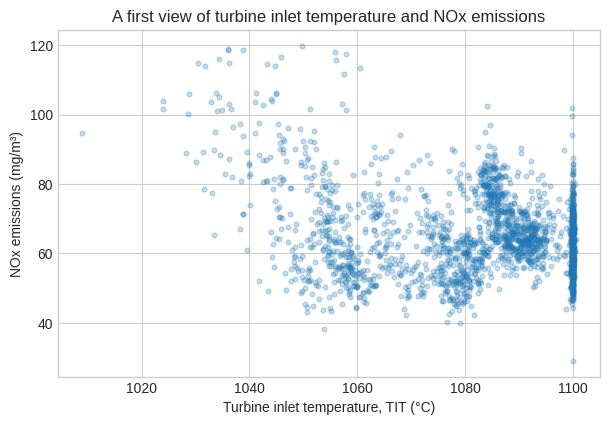

In [11]:
# Import Matplotlib only when we are ready to make a figure.
import matplotlib.pyplot as plt #导入 Matplotlib 的绘图模块。

# Use a readable plotting style for the exploratory figure below.
plt.style.use("seaborn-v0_8-whitegrid") #设置画图样式为带白色网格背景的风格，提升图表的可读性与美观度。

# Plot a reproducible subset so overlapping points do not hide the overall pattern.
# This is useful for large datasets.
plot_data = data.sample(n=2_000, random_state=4520) #由于原始数据集有上万行，数据点太密会导致重叠遮挡。因此随机抽取 2,000 条数据作为代表性子集。
#设置随机种子（使用课程代码 MECE 4520），确保每次运行代码抽选出的数据完全一致，保证结果可复现（Reproducible）。
# Each point represents one hourly turbine observation.
fig, ax = plt.subplots(figsize=(7, 4.5)) #创建宽 7 英寸、高 4.5 英寸的画布（fig）与坐标轴（ax）。
ax.scatter(plot_data["TIT"], plot_data["NOX"], alpha=0.25, s=12) #以 TIT（涡轮进口温度）为横坐标 $X$，NOX（氮氧化物排放量）为纵坐标 $Y$ 绘制散点图。
#设置数据点的透明度为 $25\%$。当多个点重叠在一起时颜色会变深，能直观展示数据密度的分布
ax.set(
    xlabel="Turbine inlet temperature, TIT (°C)",
    ylabel="NOx emissions (mg/m³)",
    title="A first view of turbine inlet temperature and NOx emissions",
) #批量设置 $X$ 轴标签（带物理单位 °C）、$Y$ 轴标签（带物理单位 $\text{mg/m}^3$）以及图表标题。
plt.show()#渲染并显示最终生成的图表。

## Check-in

1. Change the plotting code to use `AT` or `TEY` on the horizontal axis. What pattern do you see?
2. What is one question you would ask before interpreting this plot as a causal relationship?
3. In one sentence, explain the difference between a NumPy array and a Pandas DataFrame.

Keep your answers in your own notes. We will build on this dataset in the next notebook.

[Return to the Foundations page](index.qmd)